--- Model Accuracy: 85.25% ---

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



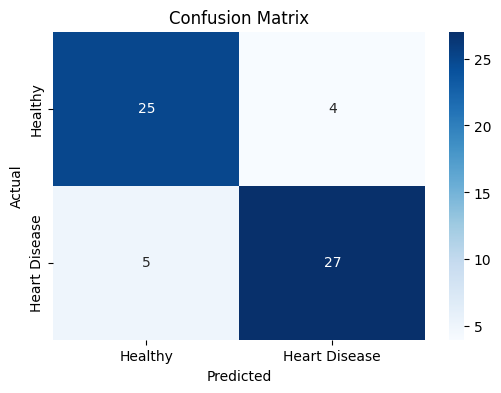

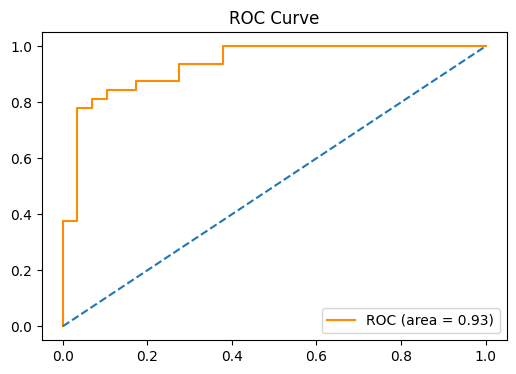

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc

# --- STEP 1: Load Data ---
# Ensure you have uploaded the CSV to Colab first!
df = pd.read_csv("Heart_disease_cleveland_new.csv")

# --- STEP 2: Prepare Data ---
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- STEP 3: Train Model (This defines 'final_model') ---
final_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
final_model.fit(X_train, y_train)

# --- STEP 4: Evaluation ---
# 1. Get Predictions
y_pred = final_model.predict(X_test)
y_probs = final_model.predict_proba(X_test)[:, 1]

# 2. Print Metrics
print(f"--- Model Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}% ---\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 3. Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Heart Disease'],
            yticklabels=['Healthy', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 4. Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC (area = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve')
plt.legend()
plt.show()